# Penyusunan Model

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer, RobustScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, mean_squared_error, classification_report

## 1. Pre-processing model -- Pembersihan data

In [3]:
df = pd.read_csv('D:\dummyML\data\polder_data_fix.csv')
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\UsHER\AppData\Local\Temp\ipykernel_12596\325939391.py:1: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv('D:\dummyML\data\polder_data_fix.csv')


,timestamp,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,Pump1,Pump2,Pump3,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,pintu,pump_on,status_banjir
0,2025-06-09 00:00:00,0.466032,2.389919,1.819317,on,on,off,0.634561,6.569780,12.875024,0.0,0.0,0.0,1.0,0.0
1,2025-06-09 00:02:27,0.470409,2.398388,1.836405,on,on,off,0.629908,6.559635,12.874414,0.0,0.0,0.0,1.0,0.0
2,2025-06-09 00:07:27,0.479342,2.415673,1.871278,on,on,off,0.620411,6.538929,12.873169,0.0,0.0,0.0,1.0,0.0
3,2025-06-09 00:12:27,0.488275,2.432957,1.906150,on,on,off,0.610914,6.518223,12.871923,0.0,0.0,0.0,1.0,0.0
4,2025-06-09 00:17:27,0.497208,2.450241,1.941023,on,on,off,0.601418,6.497517,12.870678,0.0,0.0,0.0,1.0,0.0


In [4]:
df.describe

<bound method NDFrame.describe of                  timestamp  Debit_Cipalasari  Debit_Hilir  Debit_Hulu Pump1  \
0      2025-06-09 00:00:00          0.466032     2.389919    1.819317    on   
1      2025-06-09 00:02:27          0.470409     2.398388    1.836405    on   
2      2025-06-09 00:07:27          0.479342     2.415673    1.871278    on   
3      2025-06-09 00:12:27          0.488275     2.432957    1.906150    on   
4      2025-06-09 00:17:27          0.497208     2.450241    1.941023    on   
...                    ...               ...          ...         ...   ...   
30647  2025-06-11 22:12:27          0.000000     7.724410    0.134400    on   
30648  2025-06-11 22:17:27          0.000000     7.724410    0.134400    on   
30649  2025-06-11 22:22:27          0.000000     7.724410    0.134400    on   
30650  2025-06-11 22:27:27          0.000000     7.724410    0.134400    on   
30651  2025-06-11 23:00:00          0.000000     7.724410    0.134400    on   

      Pump2 Pump3

In [5]:
#Drop kolom timestamp
df.drop('timestamp', axis=1, inplace=True)
df.head()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,Pump1,Pump2,Pump3,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,pintu,pump_on,status_banjir
0,0.466032,2.389919,1.819317,on,on,off,0.634561,6.569780,12.875024,0.0,0.0,0.0,1.0,0.0
1,0.470409,2.398388,1.836405,on,on,off,0.629908,6.559635,12.874414,0.0,0.0,0.0,1.0,0.0
2,0.479342,2.415673,1.871278,on,on,off,0.620411,6.538929,12.873169,0.0,0.0,0.0,1.0,0.0
3,0.488275,2.432957,1.906150,on,on,off,0.610914,6.518223,12.871923,0.0,0.0,0.0,1.0,0.0
4,0.497208,2.450241,1.941023,on,on,off,0.601418,6.497517,12.870678,0.0,0.0,0.0,1.0,0.0


In [6]:
# Feature engineering (Merge Pump1, Pump2, and Pump3 into a single column)
df['pump'] = df[['Pump1', 'Pump2', 'Pump3']].eq('on').sum(axis=1)
df.drop(columns=['Pump1', 'Pump2', 'Pump3'], inplace=True)
df.head()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,pintu,pump_on,status_banjir,pump
0,0.466032,2.389919,1.819317,0.634561,6.569780,12.875024,0.0,0.0,0.0,1.0,0.0,2
1,0.470409,2.398388,1.836405,0.629908,6.559635,12.874414,0.0,0.0,0.0,1.0,0.0,2
2,0.479342,2.415673,1.871278,0.620411,6.538929,12.873169,0.0,0.0,0.0,1.0,0.0,2
3,0.488275,2.432957,1.906150,0.610914,6.518223,12.871923,0.0,0.0,0.0,1.0,0.0,2
4,0.497208,2.450241,1.941023,0.601418,6.497517,12.870678,0.0,0.0,0.0,1.0,0.0,2


In [7]:
#Drop kolom bojongsoang, dayeuhkolot, pintu pump_on, dan status banjir
df.drop(columns=['bojongsoang', 'dayeuhkolot', 'pintu', 'pump_on', 'status_banjir'], inplace=True)
df.head()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,pump
0,0.466032,2.389919,1.819317,0.634561,6.569780,12.875024,2
1,0.470409,2.398388,1.836405,0.629908,6.559635,12.874414,2
2,0.479342,2.415673,1.871278,0.620411,6.538929,12.873169,2
3,0.488275,2.432957,1.906150,0.610914,6.518223,12.871923,2
4,0.497208,2.450241,1.941023,0.601418,6.497517,12.870678,2


## 2. Preprocessing model -- Transformasi data

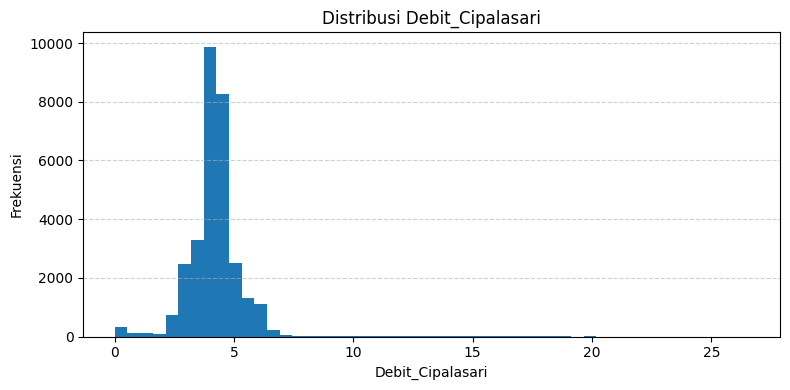

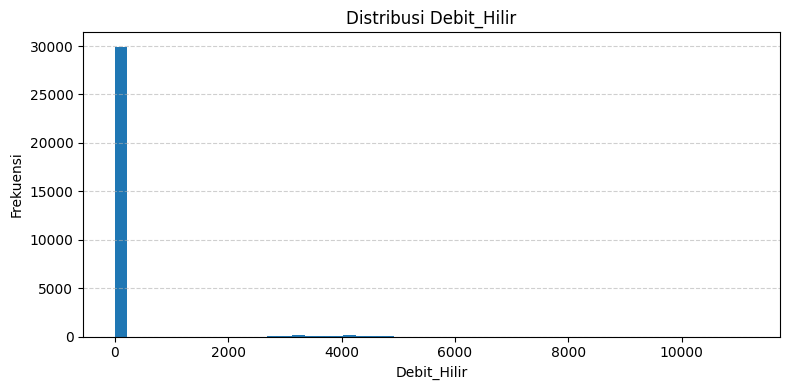

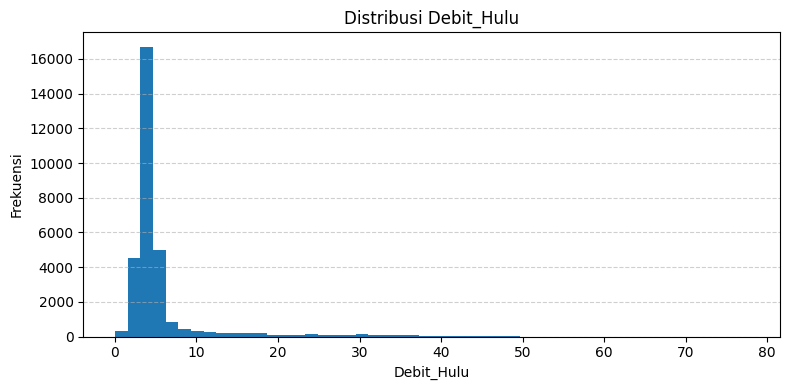

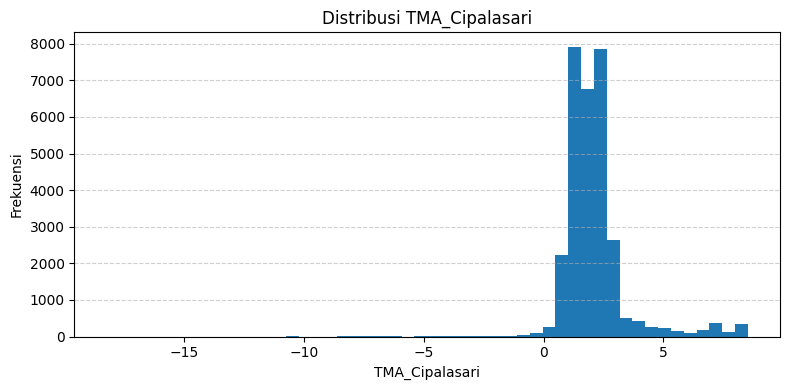

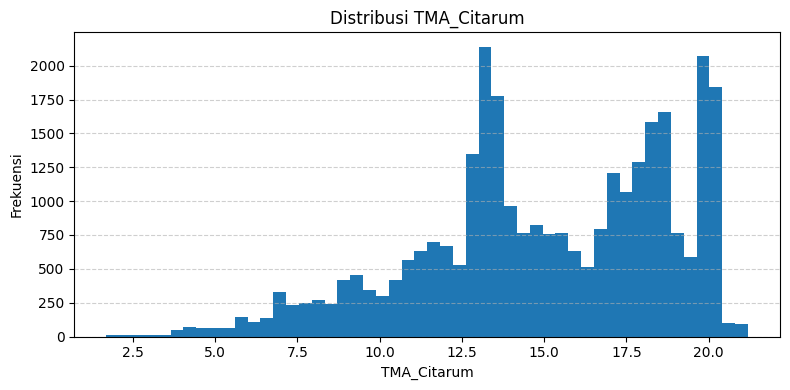

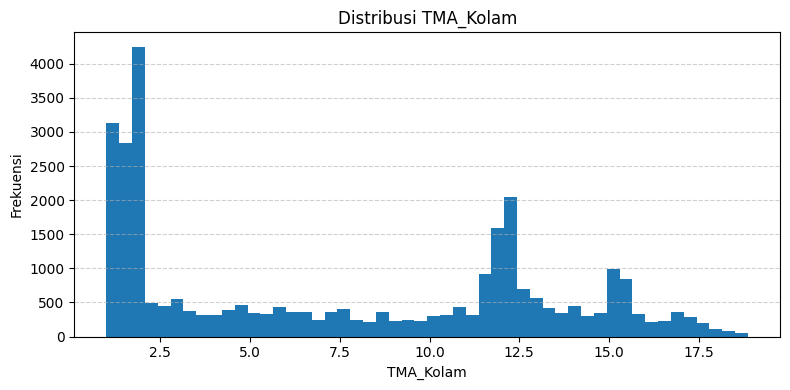

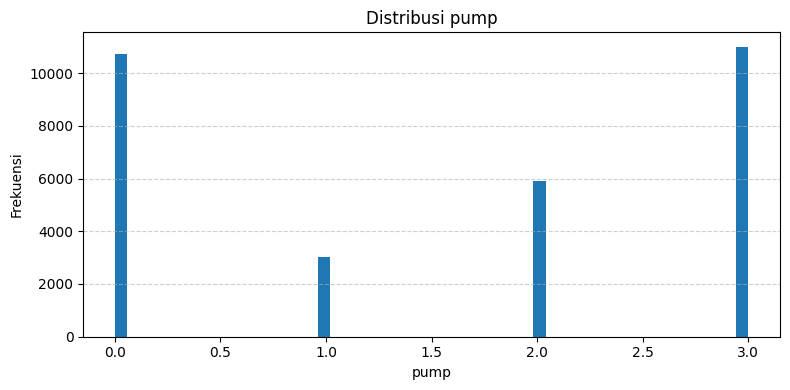

In [8]:
# Analisa distribusi data
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col].dropna(), bins=50)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

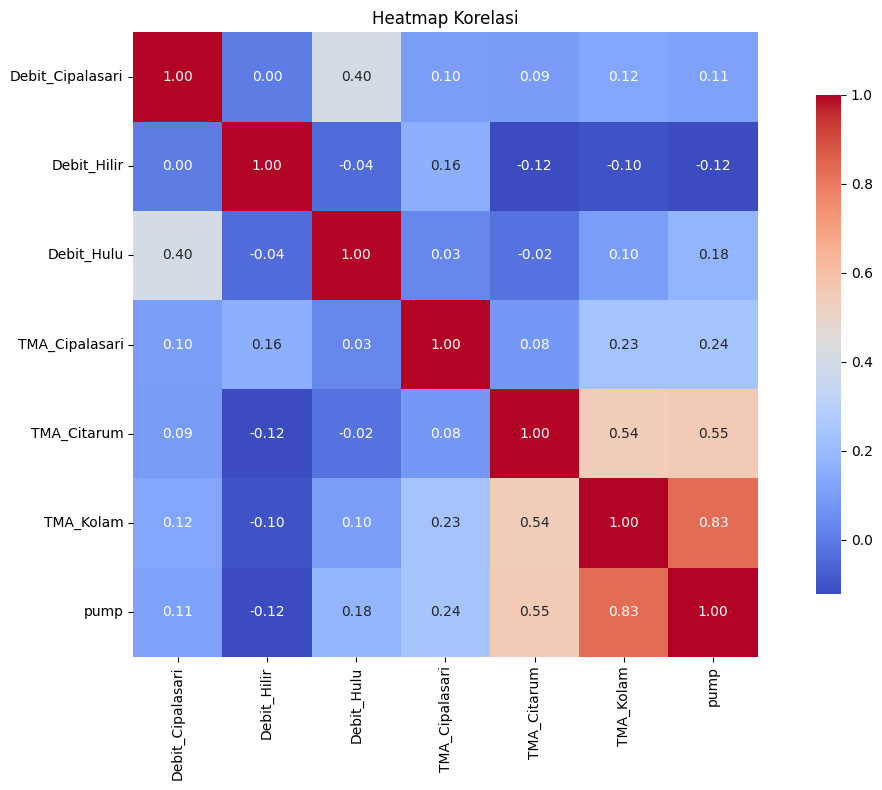

In [9]:
#lihat heatmap korelasi
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Heatmap Korelasi')
plt.tight_layout()
plt.show()

In [12]:
# 1. Debit_cipalasari

# Transformasi Logaritmik
df['Debit_Cipalasari_log'] = np.log1p(df['Debit_Cipalasari'])

# Transformasi Winsorization
df['Debit_Cipalasari_winsorized'] = stats.mstats.winsorize(df['Debit_Cipalasari'], limits=[0.05, 0.05])

# Transformasi Robust Scaler
robust_scaler = RobustScaler()
df['Debit_Cipalasari_norm'] = robust_scaler.fit_transform(df[['Debit_Cipalasari']])

# Transformasi Quantile Transformer
quantile_transformer = QuantileTransformer(output_distribution='normal')
df['Debit_Cipalasari_quantile'] = quantile_transformer.fit_transform(df[['Debit_Cipalasari']])


               variabel  skewness          stat  p_value           test
0  Debit_Cipalasari_log -2.325098  17743.332857      0.0  D’Agostino K²
                      variabel  skewness          stat       p_value  \
0         Debit_Cipalasari_log -2.325098  17743.332857  0.000000e+00   
1  Debit_Cipalasari_winsorized  0.202597    208.717279  4.760128e-46   

            test  
0  D’Agostino K²  
1  D’Agostino K²  
                      variabel  skewness          stat       p_value  \
0         Debit_Cipalasari_log -2.325098  17743.332857  0.000000e+00   
1  Debit_Cipalasari_winsorized  0.202597    208.717279  4.760128e-46   
2        Debit_Cipalasari_norm  4.244257  29049.995442  0.000000e+00   

            test  
0  D’Agostino K²  
1  D’Agostino K²  
2  D’Agostino K²  
                      variabel  skewness          stat       p_value  \
0         Debit_Cipalasari_log -2.325098  17743.332857  0.000000e+00   
1  Debit_Cipalasari_winsorized  0.202597    208.717279  4.760128e-46   
2

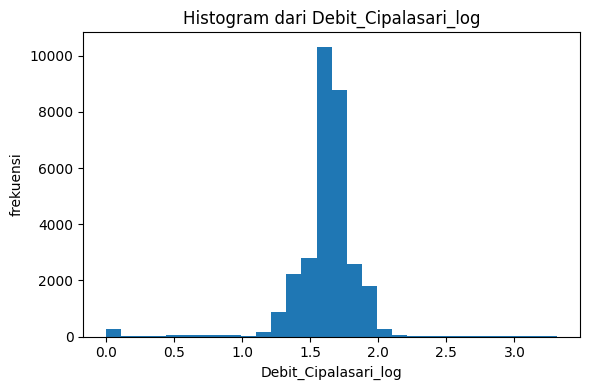

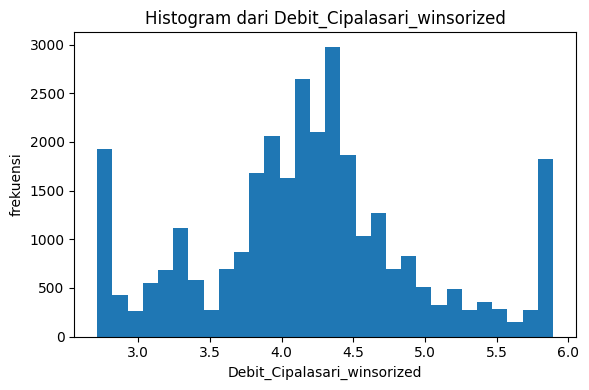

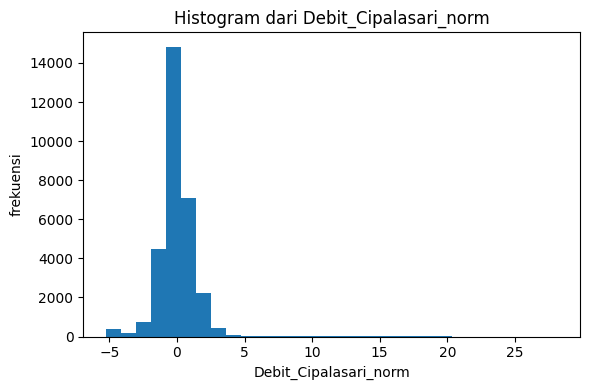

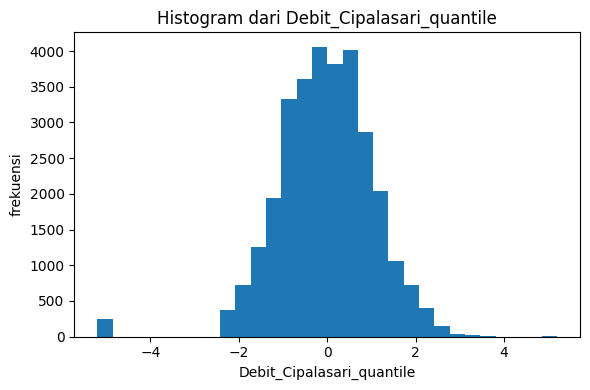

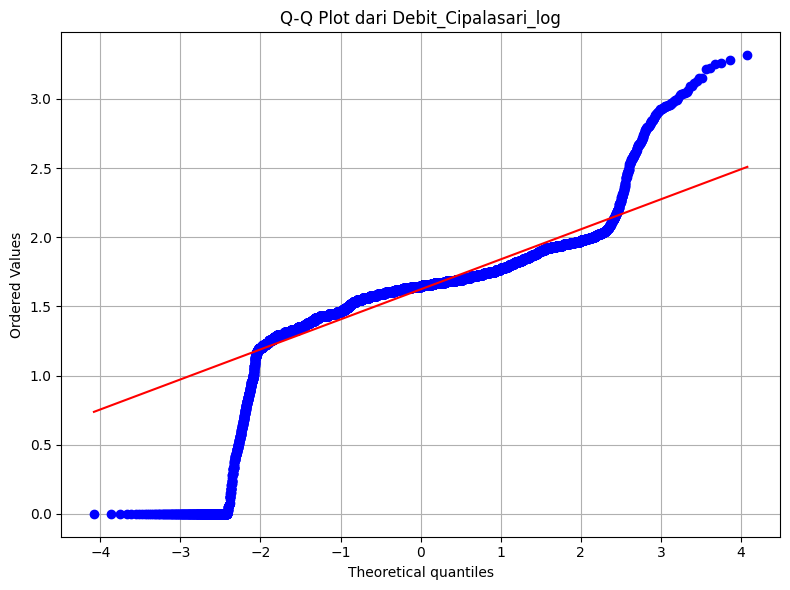

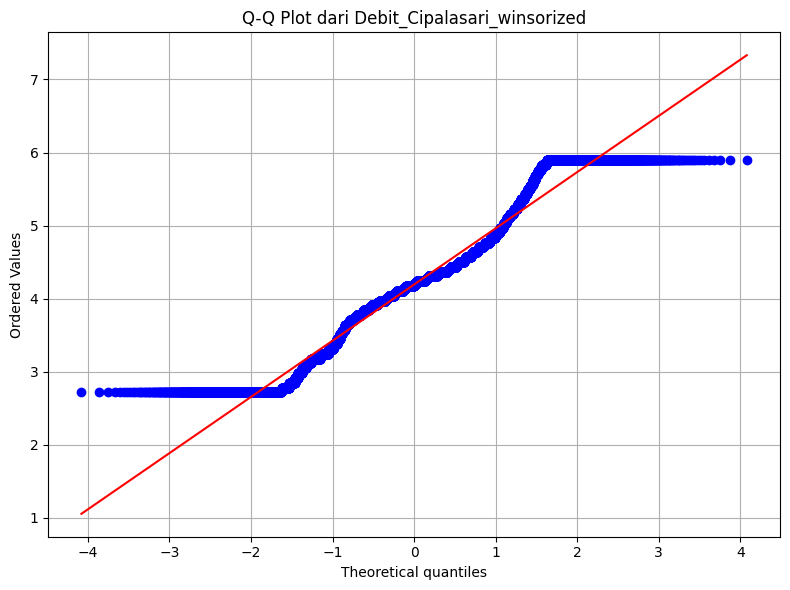

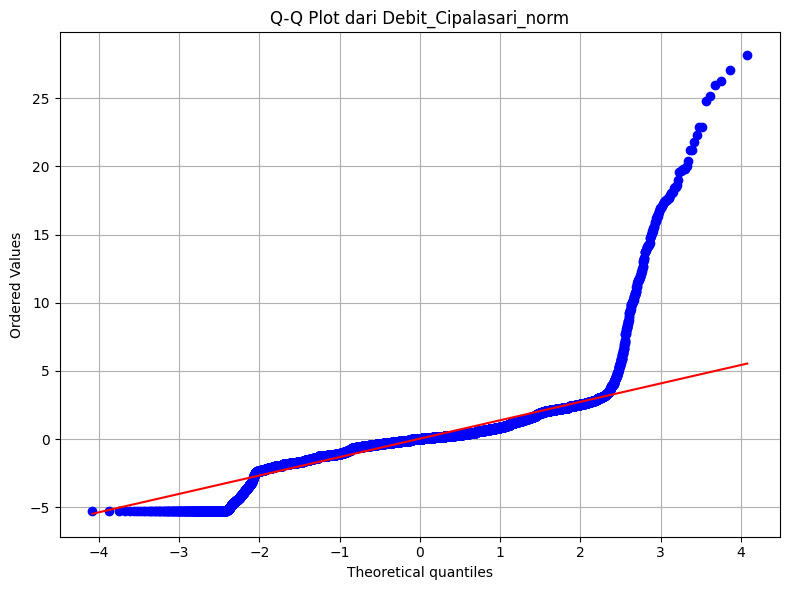

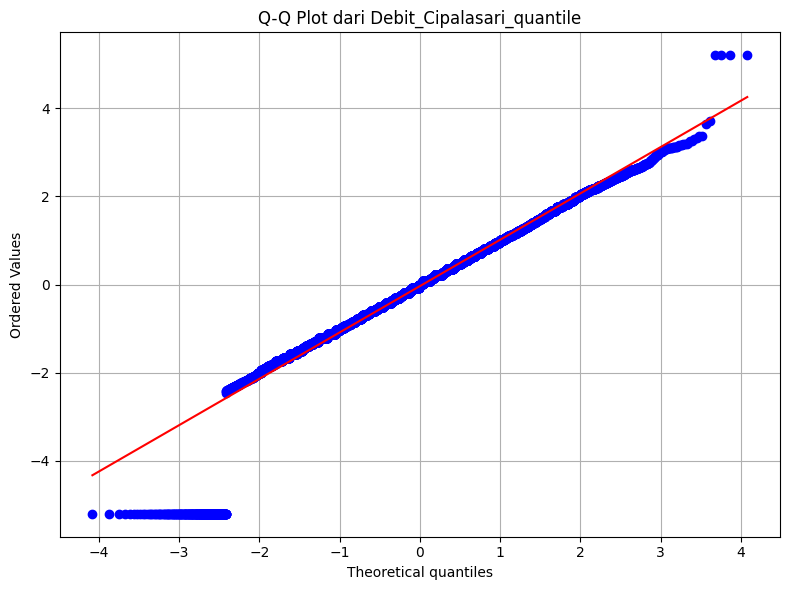

In [13]:
#Lakukan Transformasi log, winsorization, dan robust scaling pada masing masing data hidrologis
# 1. Debit_cipalasari

var = 'Debit_Cipalasari'
variants = [
    f'{var}_log',
    f'{var}_winsorized',
    f'{var}_norm',
    f'{var}_quantile'
]

hasil = []
for col in variants:
    data = df[col].dropna()
    skew = data.skew()
    if len(data) <= 5000:
        stat, p = stats.shapiro(data)
        test = 'Shapiro-Wilk'
    else:
        stat, p = stats.normaltest(data)
        test = 'D’Agostino K²'
    hasil.append({
        'variabel': col,
        'skewness': skew,
        'stat': stat,
        'p_value': p,
        'test': test
    })

    hasil_df = pd.DataFrame(hasil)
    print(hasil_df)

# lakukan statistical test menggunakan Q-Q plot 
for col in variants:
    data = df[col].dropna()
    plt.figure(figsize=(6,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram dari {col}')
    plt.xlabel(col); plt.ylabel('frekuensi')
    plt.tight_layout()
    plt.show()

for col in variants:
    plt.figure(figsize=(8, 6))
    stats.probplot(df[col].dropna(), dist="norm", plot=plt)
    plt.title(f'Q-Q Plot dari {col}')
    plt.grid()
    plt.tight_layout()
    plt.show()

In [16]:
# 1. Debit_Hulu

# Transformasi Logaritmik
df['Debit_Hulu_log'] = np.log1p(df['Debit_Hulu'])

# Transformasi Winsorization
df['Debit_Cipalasari_winsorized'] = stats.mstats.winsorize(df['Debit_Cipalasari'], limits=[0.05, 0.05])
df['Debit_Hulu_winsorized'] = stats.mstats.winsorize(df['Debit_Hulu'], limits=[0.05, 0.05])

# Transformasi Robust Scaler
robust_scaler = RobustScaler()
df['Debit_Hulu_norm'] = robust_scaler.fit_transform(df[['Debit_Hulu']])

# Transformasi Quantile Transformer
quantile_transformer = QuantileTransformer(output_distribution='normal')
df['Debit_Hulu_quantile'] = quantile_transformer.fit_transform(df[['Debit_Hulu']])


         variabel  skewness          stat  p_value           test
0  Debit_Hulu_log  1.742888  11273.934108      0.0  D’Agostino K²
                variabel  skewness          stat  p_value           test
0         Debit_Hulu_log  1.742888  11273.934108      0.0  D’Agostino K²
1  Debit_Hulu_winsorized  2.684753  16332.543557      0.0  D’Agostino K²
                variabel  skewness          stat  p_value           test
0         Debit_Hulu_log  1.742888  11273.934108      0.0  D’Agostino K²
1  Debit_Hulu_winsorized  2.684753  16332.543557      0.0  D’Agostino K²
2        Debit_Hulu_norm  3.919454  24524.609208      0.0  D’Agostino K²
                variabel  skewness          stat  p_value           test
0         Debit_Hulu_log  1.742888  11273.934108      0.0  D’Agostino K²
1  Debit_Hulu_winsorized  2.684753  16332.543557      0.0  D’Agostino K²
2        Debit_Hulu_norm  3.919454  24524.609208      0.0  D’Agostino K²
3    Debit_Hulu_quantile -0.648736   4070.860126      0.0  D’Agos

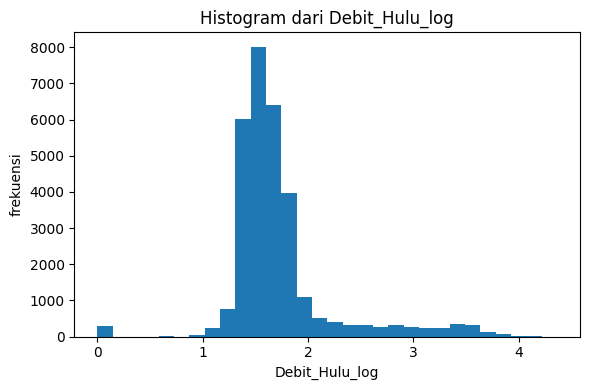

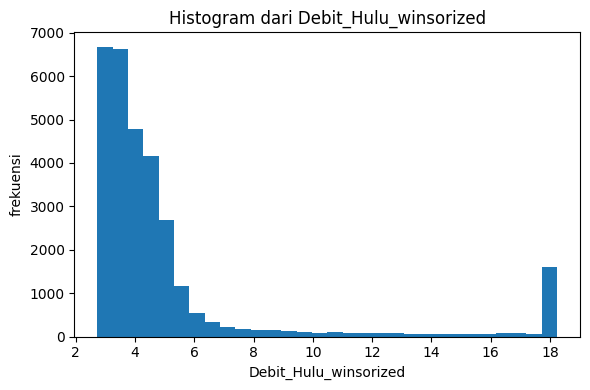

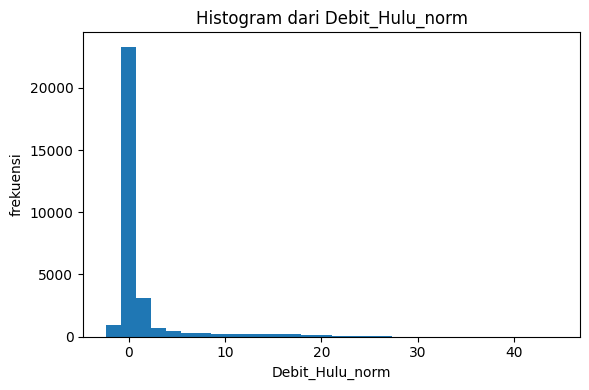

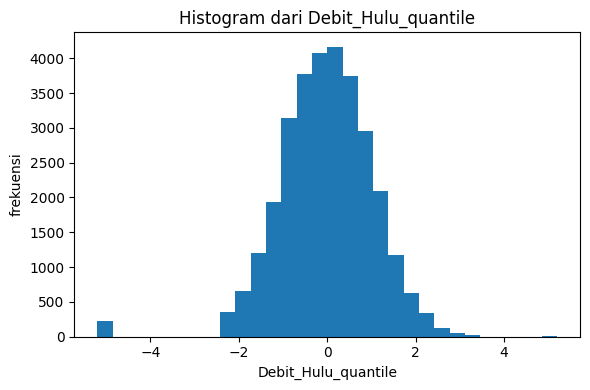

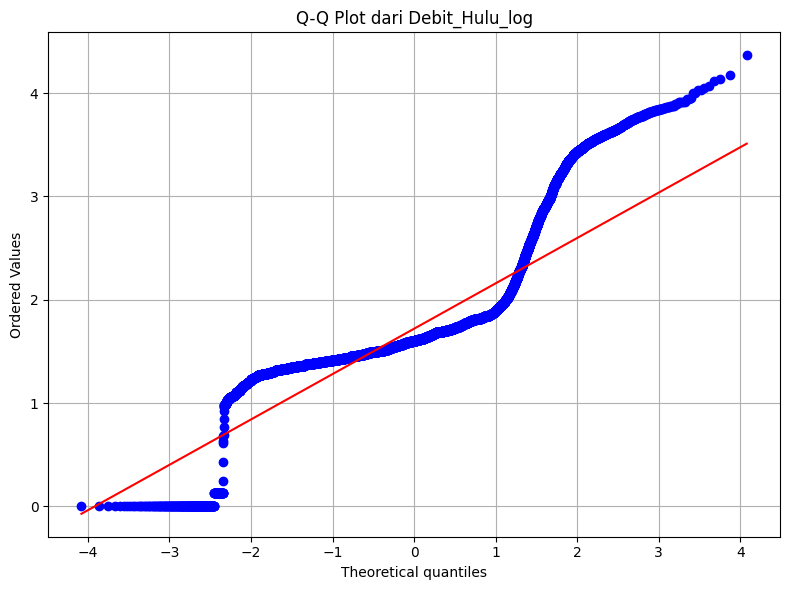

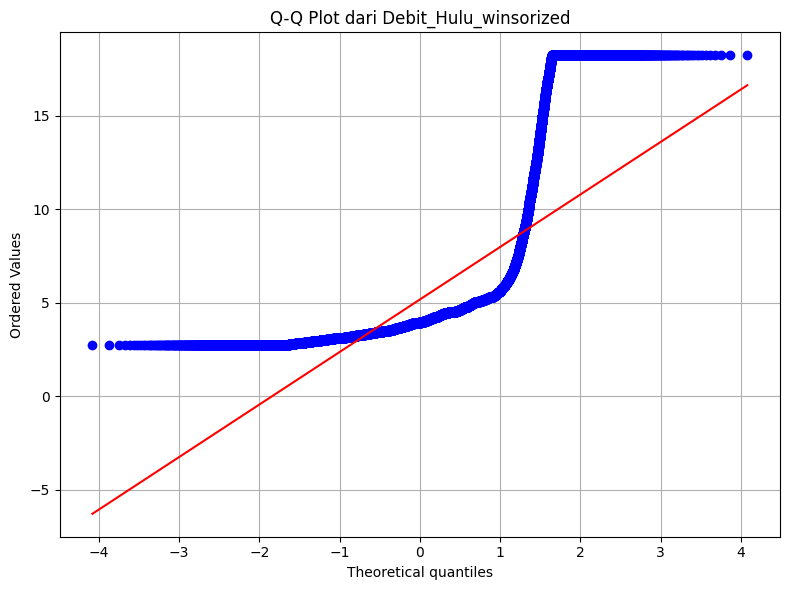

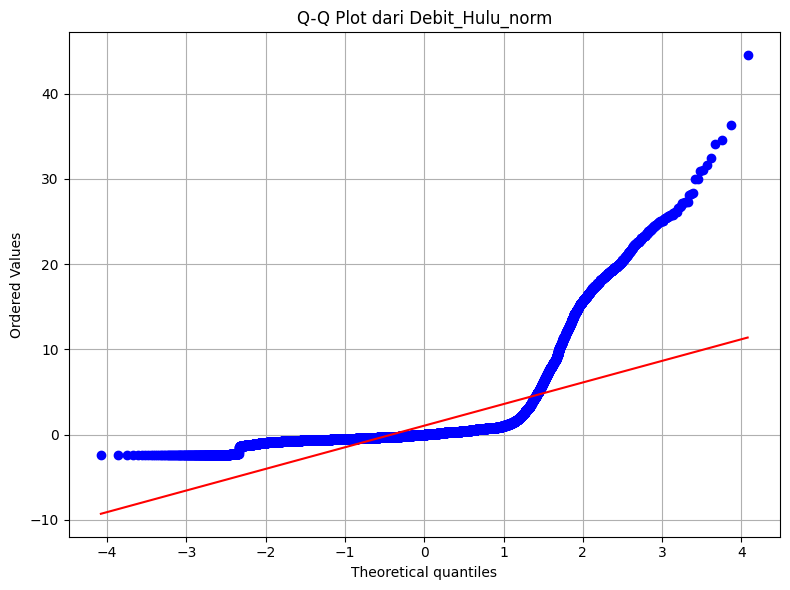

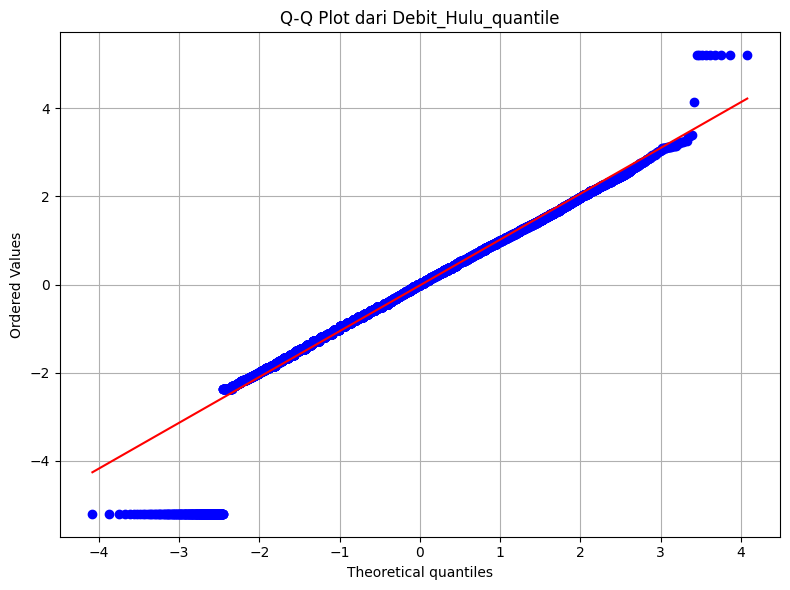

In [17]:
#Lakukan Transformasi log, winsorization, dan robust scaling pada masing masing data hidrologis
# 1. Debit_Hulu

var = 'Debit_Hulu'
variants = [
    f'{var}_log',
    f'{var}_winsorized',
    f'{var}_norm',
    f'{var}_quantile'
]

hasil = []
for col in variants:
    data = df[col].dropna()
    skew = data.skew()
    if len(data) <= 5000:
        stat, p = stats.shapiro(data)
        test = 'Shapiro-Wilk'
    else:
        stat, p = stats.normaltest(data)
        test = 'D’Agostino K²'
    hasil.append({
        'variabel': col,
        'skewness': skew,
        'stat': stat,
        'p_value': p,
        'test': test
    })

    hasil_df = pd.DataFrame(hasil)
    print(hasil_df)

# lakukan statistical test menggunakan Q-Q plot 
for col in variants:
    data = df[col].dropna()
    plt.figure(figsize=(6,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram dari {col}')
    plt.xlabel(col); plt.ylabel('frekuensi')
    plt.tight_layout()
    plt.show()

for col in variants:
    plt.figure(figsize=(8, 6))
    stats.probplot(df[col].dropna(), dist="norm", plot=plt)
    plt.title(f'Q-Q Plot dari {col}')
    plt.grid()
    plt.tight_layout()
    plt.show()